In [1]:
cd ..

/Users/julenlegido/Downloads/SpikingNeuralNetworks


In [2]:
import json
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12


def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

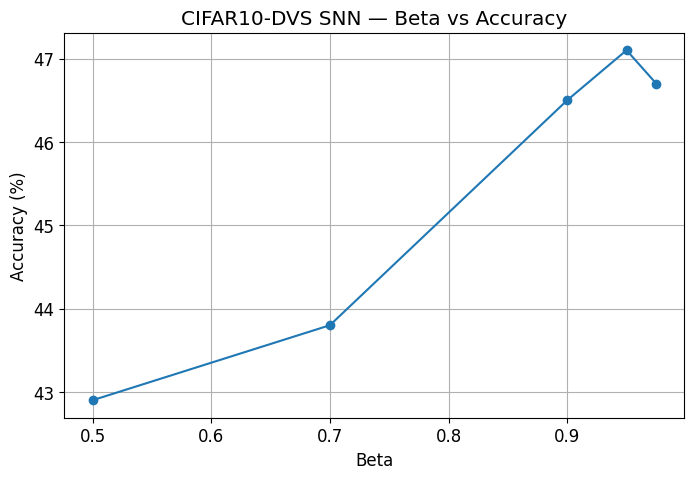

In [32]:
#beta comparison
dvs05 = load_json("results/logs/snn_dvs_T10_beta0.5.json")
dvs07 = load_json("results/logs/snn_dvs_T10_beta0.7.json")
dvs09 = load_json("results/logs/snn_dvs_T10_beta0.9.json")
dvs095 = load_json("results/logs/snn_dvs_T10_beta0.95.json")
dvs0975 = load_json("results/logs/snn_dvs_T10_beta0.975.json")

dvs_betas = [
    dvs05["beta"],
    dvs07["beta"],
    dvs09["beta"],
    dvs095["beta"],
    dvs0975["beta"]
]

dvs_acc = [
    dvs05["accuracy"][-1],
    dvs07["accuracy"][-1],
    dvs09["accuracy"][-1],
    dvs095["accuracy"][-1],
    dvs0975["accuracy"][-1]
]

plt.plot(dvs_betas, dvs_acc, marker="o")
plt.xlabel("Beta")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR10-DVS SNN — Beta vs Accuracy")
plt.grid()
plt.savefig("results/figures/beta_accuracy_comparison_CIFAR10dvs.png", dpi=300)
plt.show()

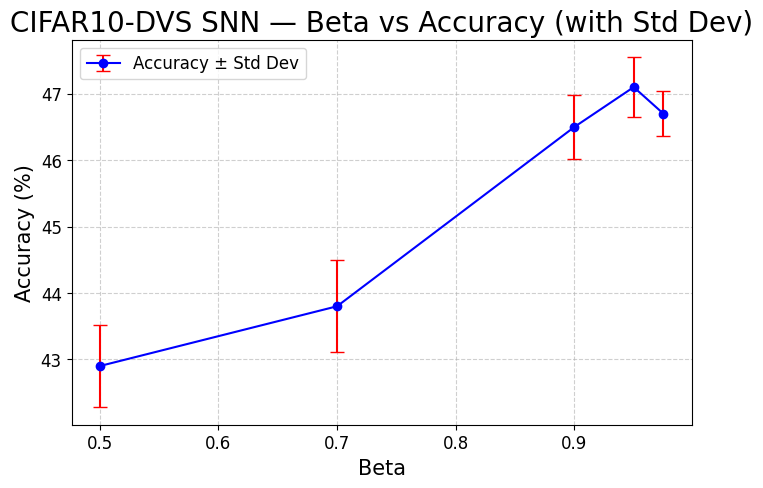

In [33]:
import numpy as np
import matplotlib.pyplot as plt

dvs05 = load_json("results/logs/snn_dvs_T10_beta0.5.json")
dvs07 = load_json("results/logs/snn_dvs_T10_beta0.7.json")
dvs09 = load_json("results/logs/snn_dvs_T10_beta0.9.json")
dvs095 = load_json("results/logs/snn_dvs_T10_beta0.95.json")
dvs0975 = load_json("results/logs/snn_dvs_T10_beta0.975.json")

dvs_betas = [
    dvs05["beta"],
    dvs07["beta"],
    dvs09["beta"],
    dvs095["beta"],
    dvs0975["beta"]
]

dvs_acc = [
    dvs05["accuracy"][-1],
    dvs07["accuracy"][-1],
    dvs09["accuracy"][-1],
    dvs095["accuracy"][-1],
    dvs0975["accuracy"][-1]
]

dvs_stds = [0.62, 0.69, 0.48, 0.45, 0.34]

plt.errorbar(
    dvs_betas,
    dvs_acc,
    yerr=dvs_stds,
    fmt="o-",       
    capsize=5,      
    ecolor="red",   
    color="blue",   
    label="Accuracy ± Std Dev"
)

plt.xlabel("Beta", fontsize=15)
plt.ylabel("Accuracy (%)", fontsize=15)
plt.title("CIFAR10-DVS SNN — Beta vs Accuracy (with Std Dev)", fontsize=20)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

#plt.savefig("results/figures/beta_accuracy_comparison_CIFAR10dvs.png", dpi=300)
plt.show()


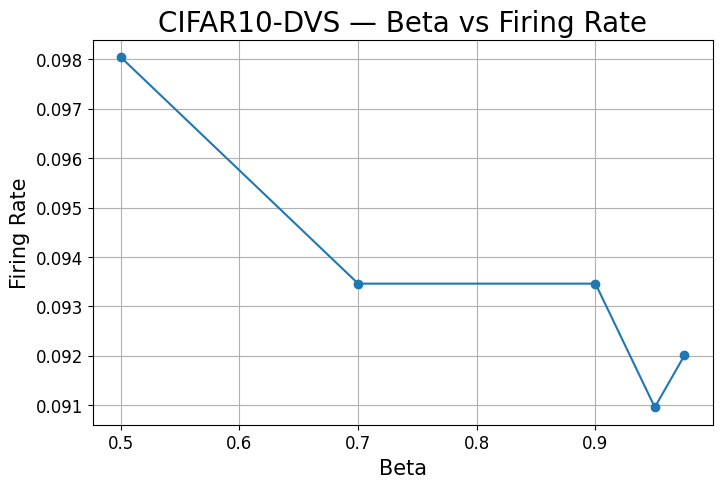

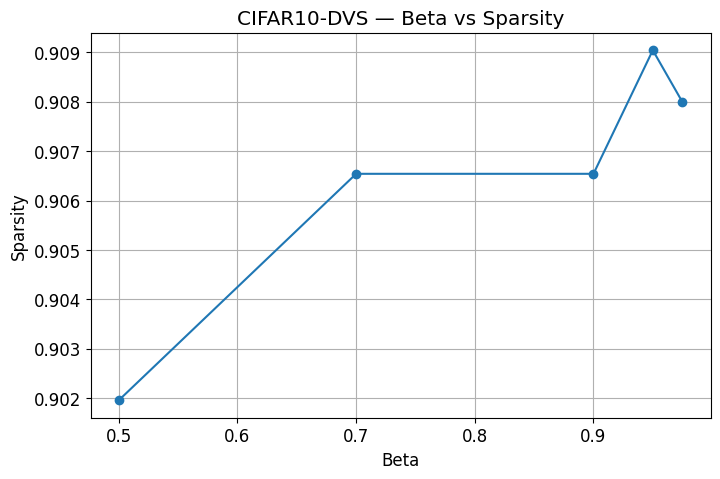

In [31]:
spk_dvs05 = load_json("results/logs/spike_analysis_dvs_T10_beta0.5.json")
spk_dvs07 = load_json("results/logs/spike_analysis_dvs_T10_beta0.7.json")
spk_dvs09 = load_json("results/logs/spike_analysis_dvs_T10_beta0.7.json")
spk_dvs095 = load_json("results/logs/spike_analysis_dvs_T10_beta0.95.json")
spk_dvs0975 = load_json("results/logs/spike_analysis_dvs_T10_beta0.975.json")

dvs_fr = [
    spk_dvs05["firing_rate"],
    spk_dvs07["firing_rate"],
    spk_dvs09["firing_rate"],
    spk_dvs095["firing_rate"],
    spk_dvs0975["firing_rate"]
]

dvs_sp = [
    spk_dvs05["sparsity"],
    spk_dvs07["sparsity"],
    spk_dvs09["sparsity"],
    spk_dvs095["sparsity"],
    spk_dvs0975["sparsity"]
]

# Firing Rate
plt.plot(dvs_betas, dvs_fr, marker="o")
plt.xlabel("Beta", fontsize=15)
plt.ylabel("Firing Rate", fontsize=15)
plt.title("CIFAR10-DVS — Beta vs Firing Rate", fontsize=20)
plt.grid()
plt.savefig("results/figures/beta_firingRate_comparison_CIFAR10dvs.png", dpi=300)
plt.show()

# Sparsity
plt.plot(dvs_betas, dvs_sp, marker="o")
plt.xlabel("Beta")
plt.ylabel("Sparsity")
plt.title("CIFAR10-DVS — Beta vs Sparsity")
plt.grid()
plt.savefig("results/figures/beta_sparsity_comparison_CIFAR10dvs.png", dpi=300)
plt.show()

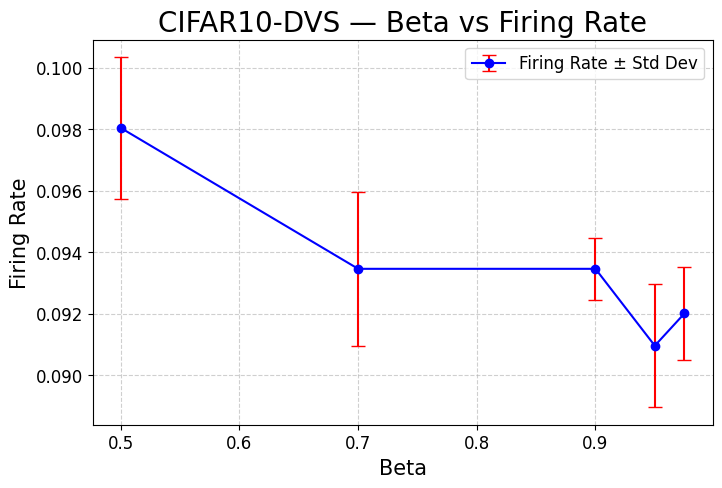

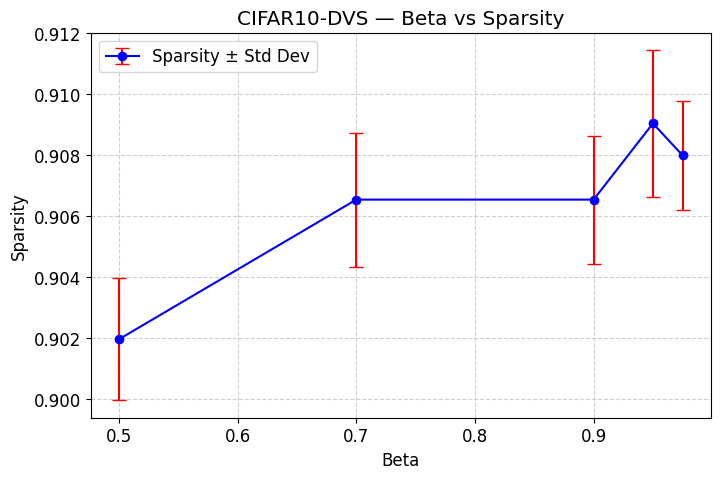

In [30]:
import numpy as np
import matplotlib.pyplot as plt

spk_dvs05 = load_json("results/logs/spike_analysis_dvs_T10_beta0.5.json")
spk_dvs07 = load_json("results/logs/spike_analysis_dvs_T10_beta0.7.json")
spk_dvs09 = load_json("results/logs/spike_analysis_dvs_T10_beta0.7.json")
spk_dvs095 = load_json("results/logs/spike_analysis_dvs_T10_beta0.95.json")
spk_dvs0975 = load_json("results/logs/spike_analysis_dvs_T10_beta0.975.json")

dvs_fr = [
    spk_dvs05["firing_rate"],
    spk_dvs07["firing_rate"],
    spk_dvs09["firing_rate"],
    spk_dvs095["firing_rate"],
    spk_dvs0975["firing_rate"],
]

dvs_sp = [
    spk_dvs05["sparsity"],
    spk_dvs07["sparsity"],
    spk_dvs09["sparsity"],
    spk_dvs095["sparsity"],
    spk_dvs0975["sparsity"],
]

fr_stds = [0.0023, 0.0025, 0.001, 0.002, 0.0015]
sp_stds = [0.002, 0.0022, 0.0021, 0.0024, 0.0018]

plt.errorbar(
    dvs_betas,
    dvs_fr,
    yerr=fr_stds,
    fmt="o-",
    capsize=5,
    ecolor="red",
    color="blue",
    label="Firing Rate ± Std Dev",
)
plt.xlabel("Beta", fontsize=15)
plt.ylabel("Firing Rate", fontsize=15)
plt.title("CIFAR10-DVS — Beta vs Firing Rate", fontsize=20)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
#plt.savefig("results/figures/beta_firingRate_comparison_CIFAR10dvs.png", dpi=300)
plt.show()

plt.errorbar(
    dvs_betas,
    dvs_sp,
    yerr=sp_stds,
    fmt="o-",
    capsize=5,
    ecolor="red",
    color="blue",
    label="Sparsity ± Std Dev",
)
plt.xlabel("Beta")
plt.ylabel("Sparsity")
plt.title("CIFAR10-DVS — Beta vs Sparsity")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
#plt.savefig("results/figures/beta_sparsity_comparison_CIFAR10dvs.png", dpi=300)
plt.show()


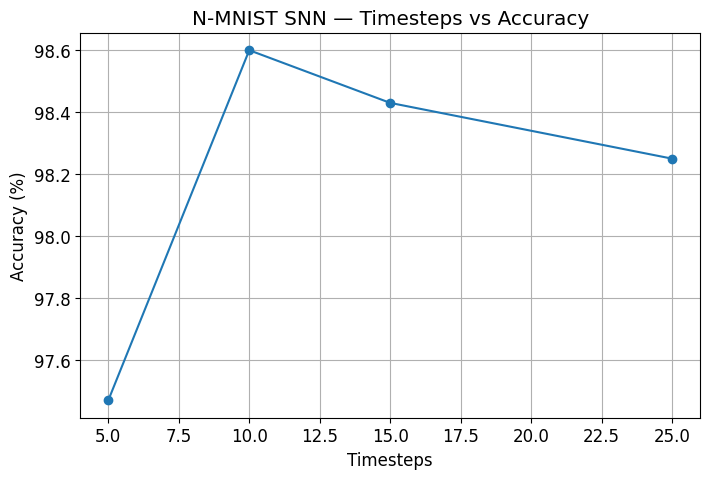

In [29]:
nmnist5 = load_json("results/logs/snn_nmnist_results_T5.json")
nmnist10 = load_json("results/logs/snn_nmnist_results_T10.json")
nmnist15 = load_json("results/logs/snn_nmnist_results_T15.json")
nmnist25 = load_json("results/logs/snn_nmnist_results_T25.json")

timesteps = [
    nmnist5["num_steps"],
    nmnist10["num_steps"],
    nmnist15["num_steps"],
    nmnist25["num_steps"]
]

accuracies = [
    nmnist5["accuracy"][-1],
    nmnist10["accuracy"][-1],
    nmnist15["accuracy"][-1],
    nmnist25["accuracy"][-1]
]

plt.plot(timesteps, accuracies, marker="o")
plt.xlabel("Timesteps")
plt.ylabel("Accuracy (%)")
plt.title("N-MNIST SNN — Timesteps vs Accuracy")
plt.grid()
plt.savefig("results/figures/nmnist_accuracies_timesteps_comparison.png", dpi=300)
plt.show()

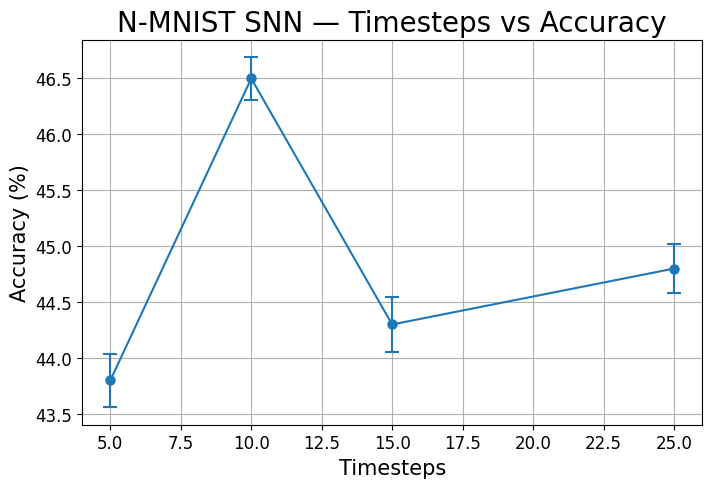

In [28]:
std_nmnist_acc = [0.24, 0.19, 0.25, 0.22]

plt.figure()

plt.errorbar(timesteps, accuracies, yerr=std_nmnist_acc, marker="o", 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)

plt.xlabel("Timesteps", fontsize=15)
plt.ylabel("Accuracy (%)", fontsize=15)
plt.title("N-MNIST SNN — Timesteps vs Accuracy", fontsize=20)
plt.grid()
#plt.savefig("results/figures/nmnist_accuracies_timesteps_comparison_with_std.png", dpi=300)
plt.show()


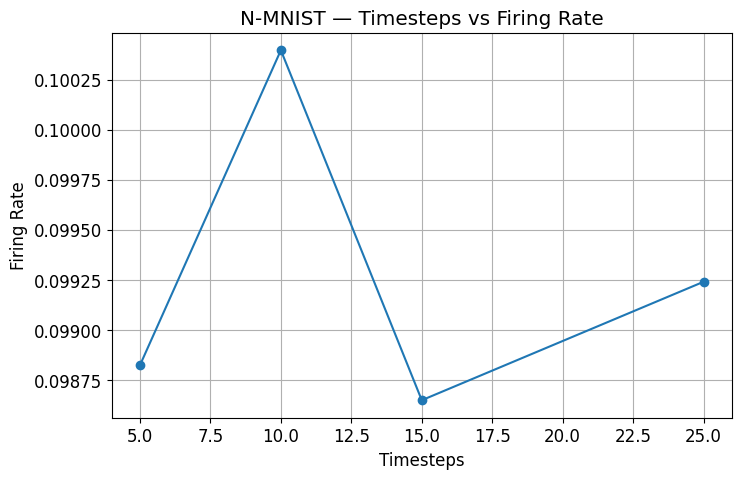

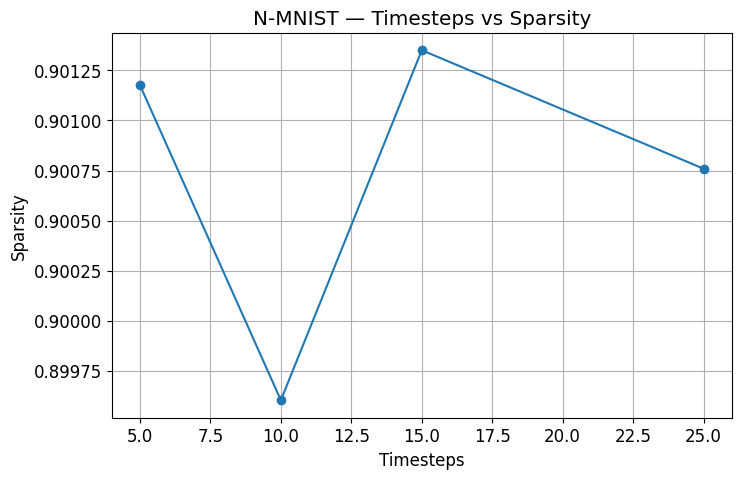

In [27]:
spk5 = load_json("results/logs/spike_analysis_nmnist_T5.json")
spk10 = load_json("results/logs/spike_analysis_nmnist_T10.json")
spk15 = load_json("results/logs/spike_analysis_nmnist_T15.json")
spk25 = load_json("results/logs/spike_analysis_nmnist_T25.json")

fr = [
    spk5["firing_rate"],
    spk10["firing_rate"],
    spk15["firing_rate"],
    spk25["firing_rate"]
]

sp = [
    spk5["sparsity"],
    spk10["sparsity"],
    spk15["sparsity"],
    spk25["sparsity"]
]

# Firing Rate
plt.plot(timesteps, fr, marker="o")
plt.xlabel("Timesteps")
plt.ylabel("Firing Rate")
plt.title("N-MNIST — Timesteps vs Firing Rate")
plt.grid()
plt.savefig("results/figures/nmnist_firingRate_timesteps_comparison.png", dpi=300)
plt.show()

# Sparsity
plt.plot(timesteps, sp, marker="o")
plt.xlabel("Timesteps")
plt.ylabel("Sparsity")
plt.title("N-MNIST — Timesteps vs Sparsity")
plt.grid()
plt.savefig("results/figures/nmnist_sparsity_timesteps_comparison.png", dpi=300)
plt.show()

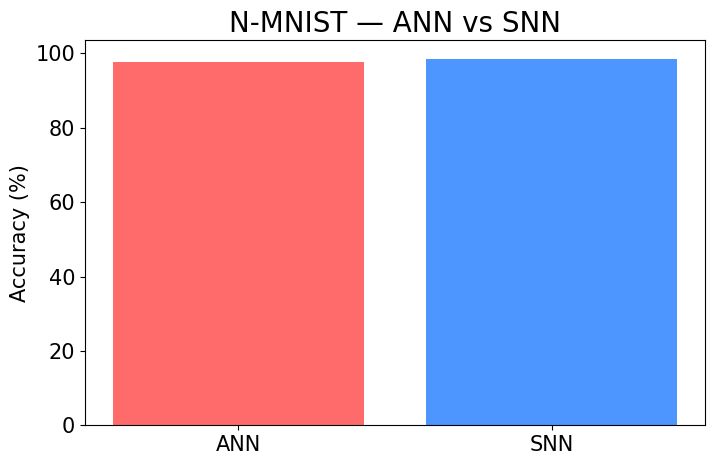

In [26]:
ann_nmnist = load_json("results/logs/ann_nmnist_results_10steps.json")
snn_nmnist = load_json("results/logs/snn_nmnist_results_T10.json")

colors = ['#FF6B6B', '#4D96FF', '#6BCB77', '#FFD93D'] 

models = ["ANN", "SNN"]

acc = [
    ann_nmnist["accuracy"][-1],
    snn_nmnist["accuracy"][-1]
]

plt.bar(models, acc, color=colors)
plt.ylabel("Accuracy (%)", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title("N-MNIST — ANN vs SNN", fontsize=20)
#plt.savefig("results/figures/nmnist_ann_snn_accuracy_comparison.png", dpi=300)
plt.show()

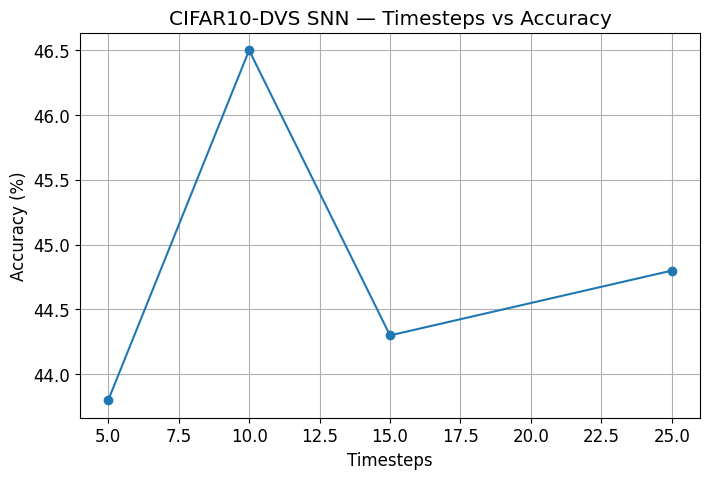

In [25]:
dvst5 = load_json("results/logs/snn_dvs_T5.json")
dvst10 = load_json("results/logs/snn_dvs_T10_beta0.9.json")
dvst15 = load_json("results/logs/snn_dvs_T15.json")
dvst25 = load_json("results/logs/snn_dvs_T25.json")

timesteps = [
    dvst5["num_steps"],
    dvst10["num_steps"],
    dvst15["num_steps"],
    dvst25["num_steps"]
]

accuracies = [
    dvst5["accuracy"][-1],
    dvst10["accuracy"][-1],
    dvst15["accuracy"][-1],
    dvst25["accuracy"][-1]
]

plt.plot(timesteps, accuracies, marker="o")
plt.xlabel("Timesteps")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR10-DVS SNN — Timesteps vs Accuracy")
plt.grid()
plt.savefig("results/figures/dvs_accuracies_timesteps_comparison.png", dpi=300)
plt.show()

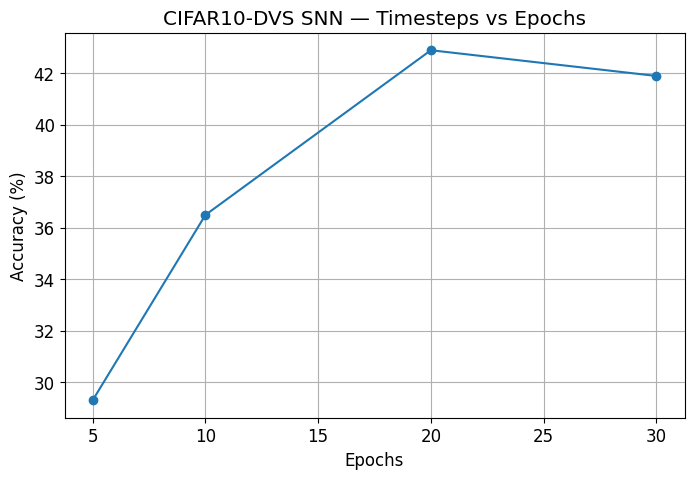

In [24]:
dvse5 = load_json("results/logs/snn_dvs_improved_5epochs.json")
dvse10 = load_json("results/logs/snn_dvs_improved_10epochs.json")
dvse20 = load_json("results/logs/snn_dvs_improved_20epochs.json")
dvse30 = load_json("results/logs/snn_dvs_improved_30epochs.json")

timesteps = [
    dvse5["epochs"],
    dvse10["epochs"],
    dvse20["epochs"],
    dvse30["epochs"]
]

accuracies = [
    dvse5["accuracy"][-1],
    dvse10["accuracy"][-1],
    dvse20["accuracy"][-1],
    dvse30["accuracy"][-1]
]

plt.plot(timesteps, accuracies, marker="o")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR10-DVS SNN — Timesteps vs Epochs")
plt.grid()
plt.savefig("results/figures/dvs_accuracies_epochs_comparison.png", dpi=300)
plt.show()


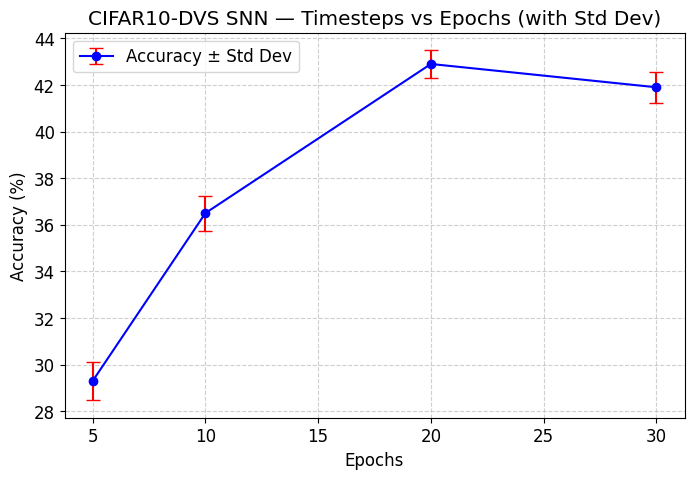

In [23]:
import numpy as np
import matplotlib.pyplot as plt

dvse5 = load_json("results/logs/snn_dvs_improved_5epochs.json")
dvse10 = load_json("results/logs/snn_dvs_improved_10epochs.json")
dvse20 = load_json("results/logs/snn_dvs_improved_20epochs.json")
dvse30 = load_json("results/logs/snn_dvs_improved_30epochs.json")

timesteps = [
    dvse5["epochs"],
    dvse10["epochs"],
    dvse20["epochs"],
    dvse30["epochs"],
]

accuracies = [
    dvse5["accuracy"][-1],
    dvse10["accuracy"][-1],
    dvse20["accuracy"][-1],
    dvse30["accuracy"][-1],
]

stds = [0.83, 0.75, 0.59, 0.67]

plt.errorbar(
    timesteps,
    accuracies,
    yerr=stds,
    fmt="o-",  # Mantiene la línea '-' y el marcador circular 'o'
    capsize=5,  # Pestañas horizontales en los extremos del error
    ecolor="red",  # Color de las barras de error (opcional)
    color="blue",  # Color de la línea y marcadores
    label="Accuracy ± Std Dev",
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR10-DVS SNN — Timesteps vs Epochs (with Std Dev)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

#plt.savefig("results/figures/dvs_accuracies_epochs_comparison.png", dpi=300)
plt.show()



In [22]:
spa5 = load_json("results/logs/spike_analysis_dvs_improved_5epochs.json")
spa10 = load_json("results/logs/spike_analysis_dvs_improved_10epochs.json")
spa20 = load_json("results/logs/spike_analysis_dvs_improved_20epochs.json")
spa30 = load_json("results/logs/spike_analysis_dvs_improved_30epochs.json")

fra = [
    spa5["firing_rate"],
    spa10["firing_rate"],
    spa20["firing_rate"],
    spa30["firing_rate"]
]

spa = [
    spa5["sparsity"],
    spa10["sparsity"],
    spa20["sparsity"],
    spa30["sparsity"]
]

# Firing Rate
plt.plot(timesteps, fr, marker="o")
plt.xlabel("Timesteps")
plt.ylabel("Firing Rate")
plt.title("CIFAR10-DVS — Timesteps vs Firing Rate")
plt.grid()
plt.savefig("results/figures/dvs_improved_firingRate_timesteps_comparison.png", dpi=300)
plt.show()

# Sparsity
plt.plot(timesteps, sp, marker="o")
plt.xlabel("Timesteps")
plt.ylabel("Sparsity")
plt.title("CIFAR10-DVS — Timesteps vs Sparsity")
plt.grid()
plt.savefig("results/figures/dvs_improved_sparsity_timesteps_comparison.png", dpi=300)
plt.show()

NameError: name 'fr' is not defined

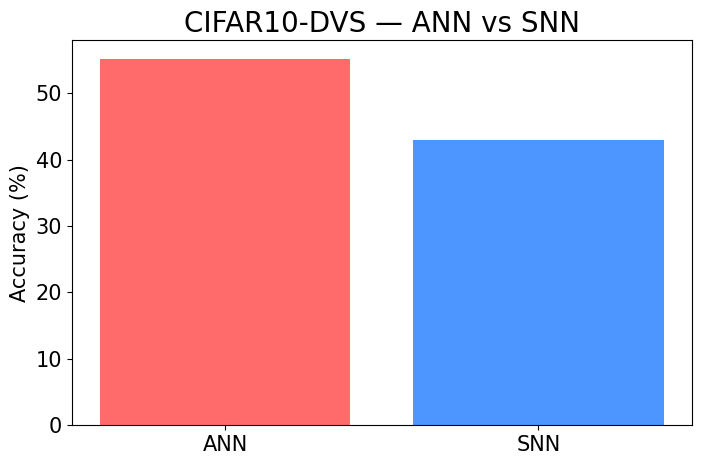

In [21]:
ann_dvs = load_json("results/logs/ann_dvs_results_20epochs.json")
snn_dvs = load_json("results/logs/snn_dvs_improved_20epochs.json")

models = ["ANN", "SNN"]

colors = ['#FF6B6B', '#4D96FF', '#6BCB77', '#FFD93D'] 


acc = [
    ann_dvs["accuracy"][-1],
    snn_dvs["accuracy"][-1]
]

plt.bar(models, acc, color=colors)
plt.ylabel("Accuracy (%)", fontsize=15)
plt.title("CIFAR10-DVS — ANN vs SNN", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#plt.savefig("results/figures/dvs_ann_snn_accuracy_comparison.png", dpi=300)
plt.show()


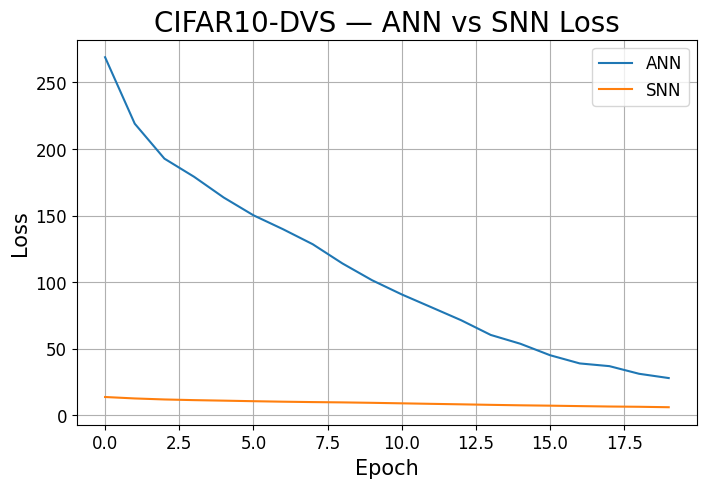

In [20]:
plt.plot(ann_dvs["loss"], label="ANN")
plt.plot(snn_dvs["loss"], label="SNN")

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.title("CIFAR10-DVS — ANN vs SNN Loss", fontsize=20)
plt.legend()
plt.grid()
#plt.savefig("results/figures/dvs_ann_snn_loss_comparison.png", dpi=300)
plt.show()


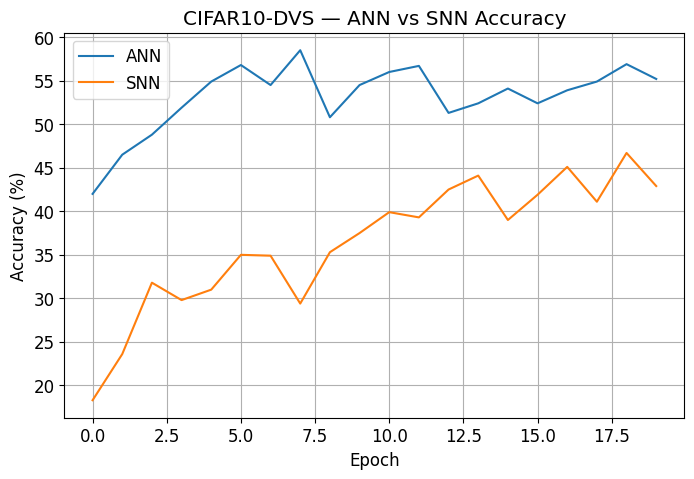

In [19]:
plt.plot(ann_dvs["accuracy"], label="ANN")
plt.plot(snn_dvs["accuracy"], label="SNN")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CIFAR10-DVS — ANN vs SNN Accuracy")
plt.legend()
plt.grid()
plt.savefig("results/figures/dvs_ann_snn_accuracy_timesteps.png", dpi=300)
plt.show()

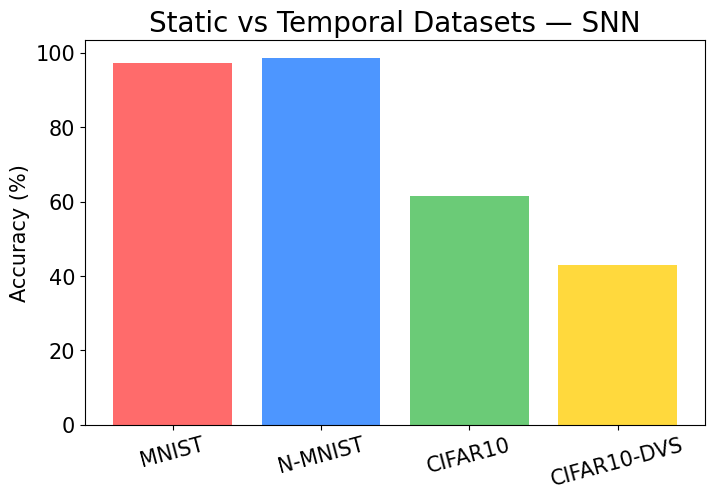

In [36]:
mnist_static = load_json("results/logs/snn_rate_results_steps25_scale0.8.json")
cifar_static = load_json("results/logs/snn_MSEKaimingImproved_beta0.5_T15.json")

datasets = [
    "MNIST",
    "N-MNIST",
    "CIFAR10",
    "CIFAR10-DVS"
]

colors = ['#FF6B6B', '#4D96FF', '#6BCB77', '#FFD93D'] 

acc = [
    mnist_static["accuracy"][-1],
    snn_nmnist["accuracy"][-1],
    cifar_static["accuracy"][-1],
    snn_dvs["accuracy"][-1]
]

plt.bar(datasets, acc, color=colors)
plt.ylabel("Accuracy (%)", fontsize=15)
plt.title("Static vs Temporal Datasets — SNN", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xticks(rotation=15)
#plt.savefig("results/figures/static_temporal_accuracy_comparison.png", dpi=300)
plt.show()

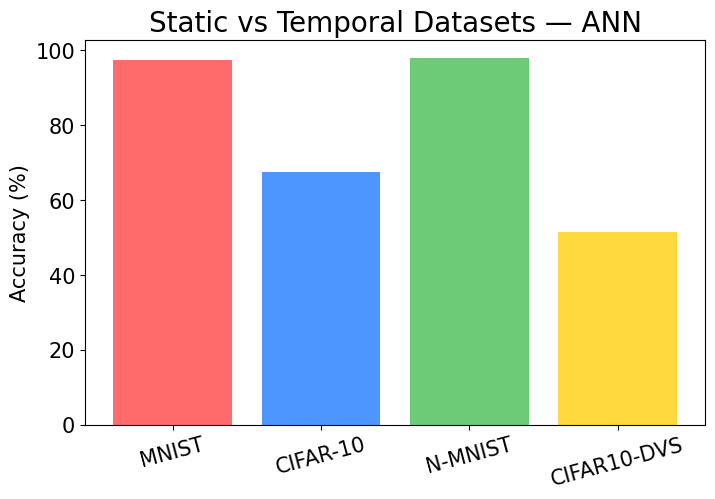

In [37]:
mnist_staticANN = load_json("results/logs/ann_results_50.json")
cifar_staticANN = load_json("results/logs/ann_cifar_results.json")
nmnist_ANN = load_json("results/logs/ann_nmnist_seed_summary.json")
dvs_ANN = load_json("results/logs/ann_dvs_seed_summary.json")

datasets = [
    "MNIST",
    "CIFAR-10",
    "N-MNIST",
    "CIFAR10-DVS"
]

colors = ['#FF6B6B', '#4D96FF', '#6BCB77', '#FFD93D'] 

acc = [
    mnist_staticANN["accuracy"][-1],
    cifar_staticANN["accuracy"][-1],
    nmnist_ANN["mean_final_accuracy"],
    dvs_ANN["mean_final_accuracy"]
]

plt.bar(datasets, acc, color=colors)
plt.ylabel("Accuracy (%)", fontsize=15)
plt.title("Static vs Temporal Datasets — ANN", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xticks(rotation=15)
#plt.savefig("results/figures/static_temporal_accuracy_comparison_ANN.png", dpi=300)
plt.show()

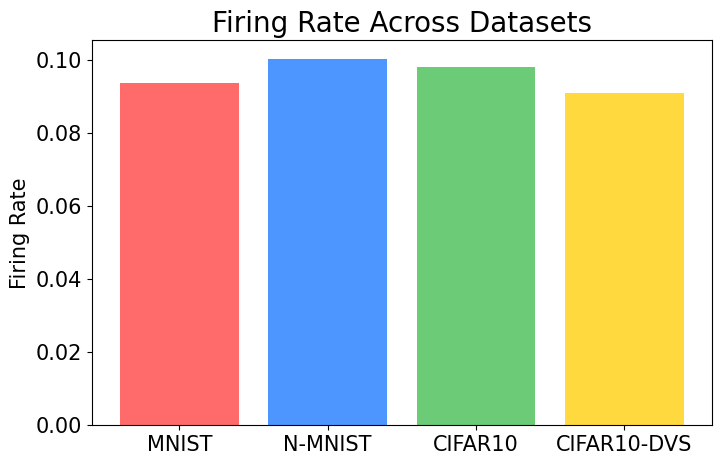

In [34]:
datasets = [
    "MNIST",
    "N-MNIST",
    "CIFAR10",
    "CIFAR10-DVS"
]

smnist_static = load_json("results/logs/spike_rate_results_steps25_scale0.8.json")
scifar_static = load_json("results/logs/spike_analysis_beta0.5_T15.json")


colors = ['#FF6B6B', '#4D96FF', '#6BCB77', '#FFD93D'] 

fr = [
    smnist_static["firing_rate"],
    spk10["firing_rate"],
    scifar_static["firing_rate"],
    spk_dvs095["firing_rate"]
]

plt.bar(datasets, fr, color=colors)
plt.ylabel("Firing Rate", fontsize =15)
plt.title("Firing Rate Across Datasets", fontsize =20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#plt.savefig("results/figures/static_temporal_firingRate_comparison.png", dpi=300)
plt.show()

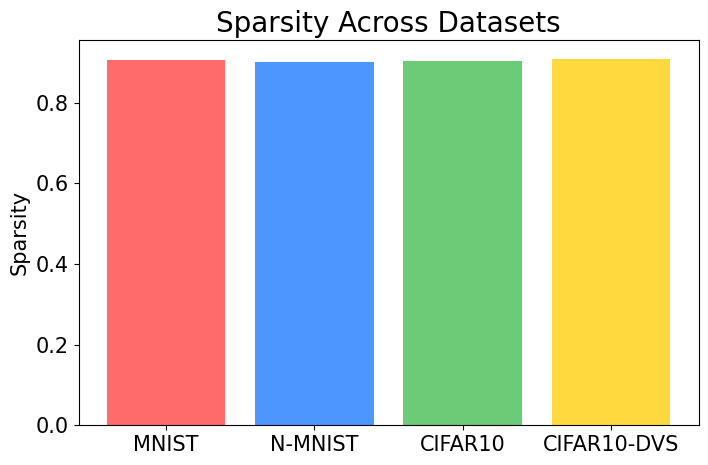

In [35]:
sp = [
    smnist_static["sparsity"],
    spk10["sparsity"],
    scifar_static["sparsity"],
    spk_dvs095["sparsity"]
]

colors = ['#FF6B6B', '#4D96FF', '#6BCB77', '#FFD93D'] 

plt.bar(datasets, sp, color=colors)
plt.ylabel("Sparsity", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title("Sparsity Across Datasets", fontsize=20)
#plt.savefig("results/figures/static_temporal_sparsity_comparison.png", dpi=300)
plt.show()

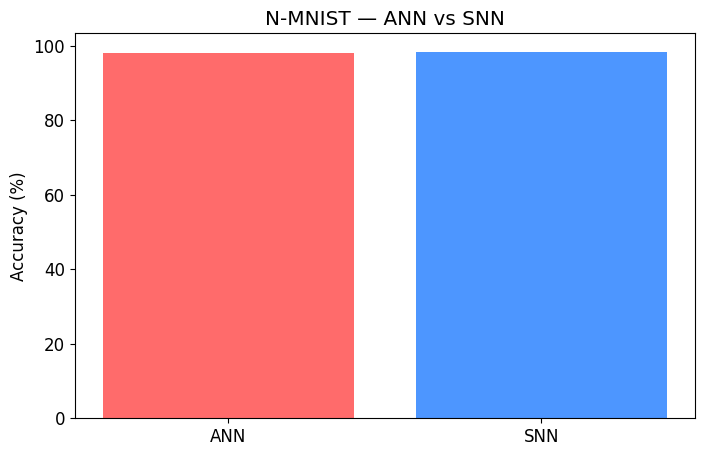

In [7]:
ann_nmnist2 = load_json("results/logs/ann_nmnist_seed_summary.json")
snn_nmnist2 = load_json("results/logs/snn_nmnist_seed_summary.json")

colors = ['#FF6B6B', '#4D96FF', '#6BCB77', '#FFD93D'] 


models = ["ANN", "SNN"]

acc = [
    ann_nmnist2["mean_best_accuracy"],
    snn_nmnist2["mean_best_accuracy"]
]

plt.bar(models, acc, color = colors)
plt.ylabel("Accuracy (%)")
plt.title("N-MNIST — ANN vs SNN")
#plt.savefig("results/figures/nmnist_ann_snn_accuracy_comparison.png", dpi=300)
plt.show()